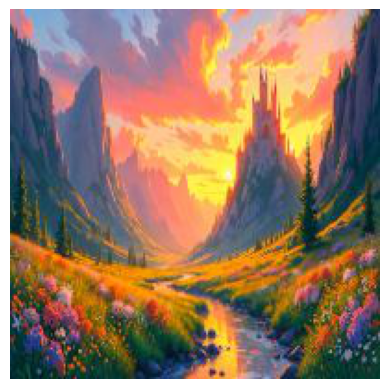

In [17]:
#1
import matplotlib.pyplot as plt
image= plt.imread(r"C:\Users\aparn\MTech26\crop_merge\image.jpg")
plt.imshow(image)
plt.axis("off")
plt.show()

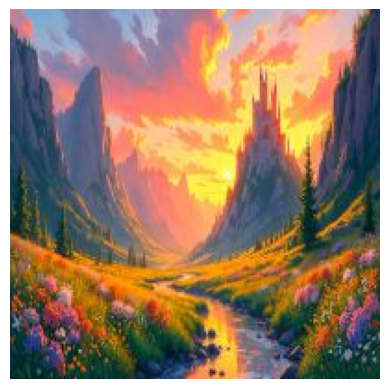

In [16]:
#2
import cv2
import matplotlib.pyplot as plt
import numpy as np
image = cv2.imread(r"C:\Users\aparn\MTech26\crop_merge\image.jpg")
image_rgb = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
r = image_rgb[:,:,0]
g = image_rgb[:,:,1]
b = image_rgb[:,:,2]

r_normalize= r.astype(float)
g_normalize= g.astype(float)
b_normalize= b.astype(float)
R= (r_normalize-r_normalize.mean())/r_normalize.std()
G= (g_normalize-g_normalize.mean())/g_normalize.std()
B= (b_normalize-b_normalize.mean())/b_normalize.std()

normalized_RGB= np.stack([r_normalize,g_normalize,b_normalize],axis=2)
normalized_RGB_min= normalized_RGB.min()
normalized_RGB_max= normalized_RGB.max()
normalized_RGB_final= (normalized_RGB-normalized_RGB_min)/(normalized_RGB_max-normalized_RGB_min)
plt.imshow(normalized_RGB_final)
plt.axis("off")
plt.show()

In [ ]:
#3
print(f"Dimention (Height, Width, Channels) of the normalised image is : {normalized_RGB_final.shape}")
print(f"Data type of the image is {normalized_RGB_final.dtype}")
height, width = normalized_RGB_final.shape[:2]
print(f"Total number of pixels in the image is {height*width}")

Dimention (Height, Width, Channels) of the normalised image is : (200, 200, 3)
Data type of the image is float64
Total number of pixels in the image is 40000


<function matplotlib.pyplot.show(close=None, block=None)>

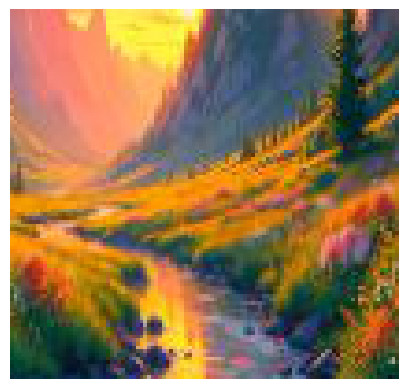

In [15]:
 #4
from PIL import Image 
import matplotlib.pyplot as plt
img= Image.open(r"C:\Users\aparn\MTech26\crop_merge\image.jpg")
box = (70,90,175,190)
cropped = img.crop(box)
plt.imshow(cropped)
plt.axis("off")
plt.show


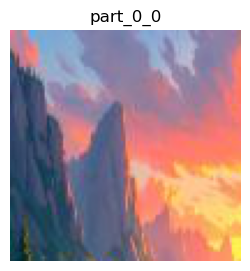

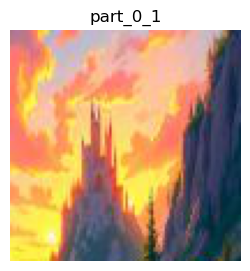

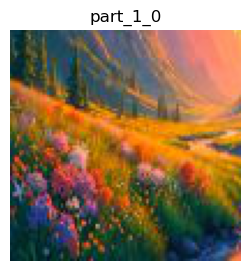

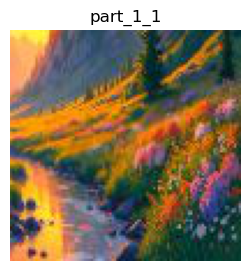

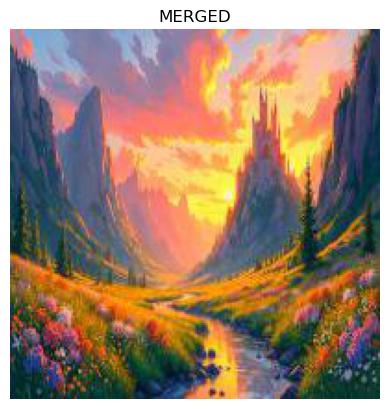

In [ ]:
#5
from PIL import Image
import os
output= r"C:\Users\aparn\MTech26\crop_merge"
img = Image.open(r"C:\Users\aparn\MTech26\crop_merge\image.jpg")
Width , Height= img._size
row = 2
col = 2 
part_width = Width//col
part_Height = Height//row

for r in range(row):
    for c in range(col):
        left = c * part_width
        upper = r * part_Height
        right = left + part_width
        lower = upper + part_Height


        box = (left,upper,right,lower)
        cropped = img.crop(box)  

        file_name = f"part_{r}_{c}.jpg"
        saving_path = os.path.join(output,file_name)
        cropped.save(saving_path)

        plt.figure(figsize=(3, 3))
        plt.imshow(cropped)
        plt.title(f"part_{r}_{c}")
        plt.axis("off")
        plt.show()


        
#Merge

part_0_0 = Image.open(r"C:\Users\aparn\MTech26\crop_merge\part_0_0.jpg")
part_0_1 = Image.open(r"C:\Users\aparn\MTech26\crop_merge\part_0_1.jpg")
part_1_0 = Image.open(r"C:\Users\aparn\MTech26\crop_merge\part_1_0.jpg")
part_1_1 = Image.open(r"C:\Users\aparn\MTech26\crop_merge\part_1_1.jpg")

width, height = part_0_0.size
merged_img = Image.new("RGB", (width * 2, height * 2))
merged_img.paste(part_0_0, (0,0))
merged_img.paste(part_0_1, (width, 0))
merged_img.paste(part_1_0, (0,height))
merged_img.paste(part_1_1, (width,height))

file1 = f"merged_final.jpg"
saving_path = os.path.join(output,file1)
merged_img.save(saving_path)
plt.imshow(merged_img)
plt.title(f"MERGED")
plt.axis("off")
plt.show()


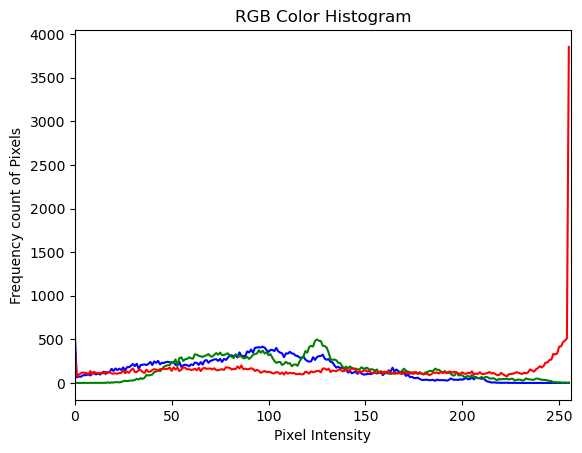

In [14]:
#6
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(r"C:\Users\aparn\MTech26\crop_merge\image.jpg")

colors = ('b', 'g', 'r')

plt.figure()
plt.title("RGB Color Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency count of Pixels")

# Loop over each color channel, compute the histogram, and plot it
for i, col in enumerate(colors):
    hist = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(hist, color=col)
    plt.xlim([0, 256])

plt.show()


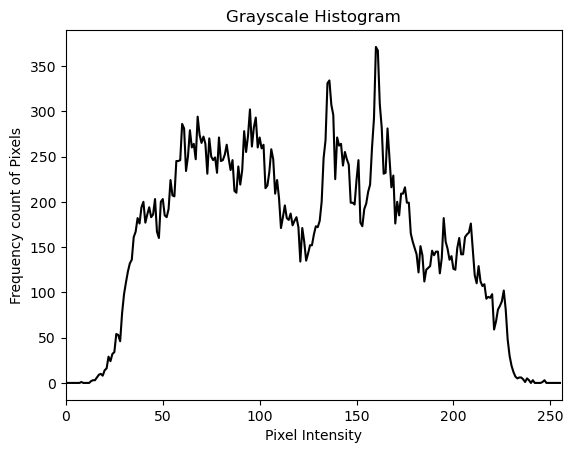

In [12]:
#7
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(r"C:\Users\aparn\MTech26\crop_merge\image.jpg")
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_hist = cv2.calcHist([gray_img], [0], None, [256], [0, 256])

plt.figure()
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency count of Pixels")
plt.plot(gray_hist, color='black') 
plt.xlim([0, 256])
plt.show()


Zoomed In Image Shape:  (400, 400, 3)
Zoomed Out Image Shape: (100, 100, 3)


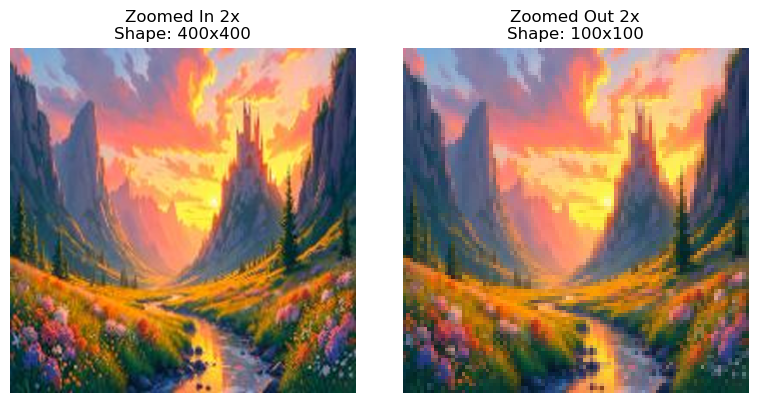

In [11]:
#8
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(r"C:\Users\aparn\MTech26\crop_merge\image.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
height, width = img_rgb.shape[:2]

# 1. Zoom In 2x (Double the size)
zoom_in = cv2.resize(img_rgb, (width * 2, height * 2), interpolation=cv2.INTER_CUBIC)

# 2. Zoom Out 2x (Half the size)
zoom_out = cv2.resize(img_rgb, (width // 2,height // 2), interpolation=cv2.INTER_AREA)

print(f"Zoomed In Image Shape:  {zoom_in.shape}")
print(f"Zoomed Out Image Shape: {zoom_out.shape}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Plot Zoomed In
axes[0].imshow(zoom_in)
axes[0].set_title(f"Zoomed In 2x\nShape: {zoom_in.shape[1]}x{zoom_in.shape[0]}")
axes[0].axis('off')

# Plot Zoomed Out
axes[1].imshow(zoom_out)
axes[1].set_title(f"Zoomed Out 2x\nShape: {zoom_out.shape[1]}x{zoom_out.shape[0]}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Original Shape (Layer 0):  (200, 200, 3)
Downsampled 1x (Layer 1): (100, 100, 3)
Downsampled 2x (Layer 2): (50, 50, 3)


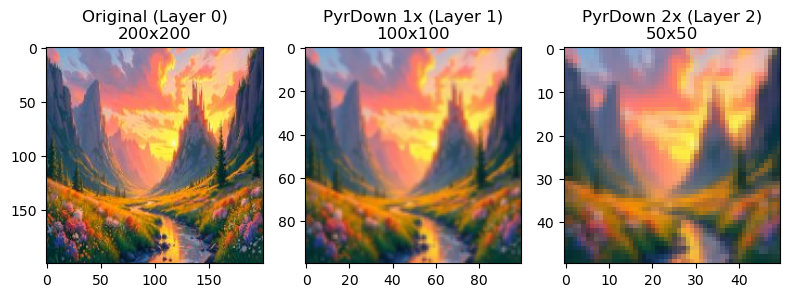

In [10]:
#9
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(r"C:\Users\aparn\MTech26\crop_merge\image.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

layer_0 = img_rgb                  
layer_1 = cv2.pyrDown(layer_0)     
layer_2 = cv2.pyrDown(layer_1)     

print(f"Original Shape (Layer 0):  {layer_0.shape}")
print(f"Downsampled 1x (Layer 1): {layer_1.shape}")
print(f"Downsampled 2x (Layer 2): {layer_2.shape}")

fig, axes = plt.subplots(1, 3, figsize=(8, 4))

axes[0].imshow(layer_0)
axes[0].set_title(f"Original (Layer 0)\n{layer_0.shape[1]}x{layer_0.shape[0]}")
axes[0].axis('on') 

axes[1].imshow(layer_1)
axes[1].set_title(f"PyrDown 1x (Layer 1)\n{layer_1.shape[1]}x{layer_1.shape[0]}")
axes[1].axis('on')

axes[2].imshow(layer_2)
axes[2].set_title(f"PyrDown 2x (Layer 2)\n{layer_2.shape[1]}x{layer_2.shape[0]}")
axes[2].axis('on')

plt.tight_layout()
plt.show()
